# Task 4: Data Visualization

1. Import visualization libraries (matplotlib, seaborn)
2. Select appropriate visualization techniques for the data:
- Bar plot for average rentals by Seasons
- Line plot showing hourly rentals throughout the day
- Heatmap showing correlation among numerical variables
- Box plot to identify outliers in Temperature and Rented Bike Count
3. Record observations and insights from visualizations
4. Save plots and observations for reporting purposes

## Bar plot for average rentals by Seasons
- show the average rentals per season

/var/folders/dx/86cvpn0169sd3sqctx9wcxgr0000gn/T/ipykernel_73252/23872209.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_avg, x='Seasons', y='Rented Bike Count', palette='viridis')


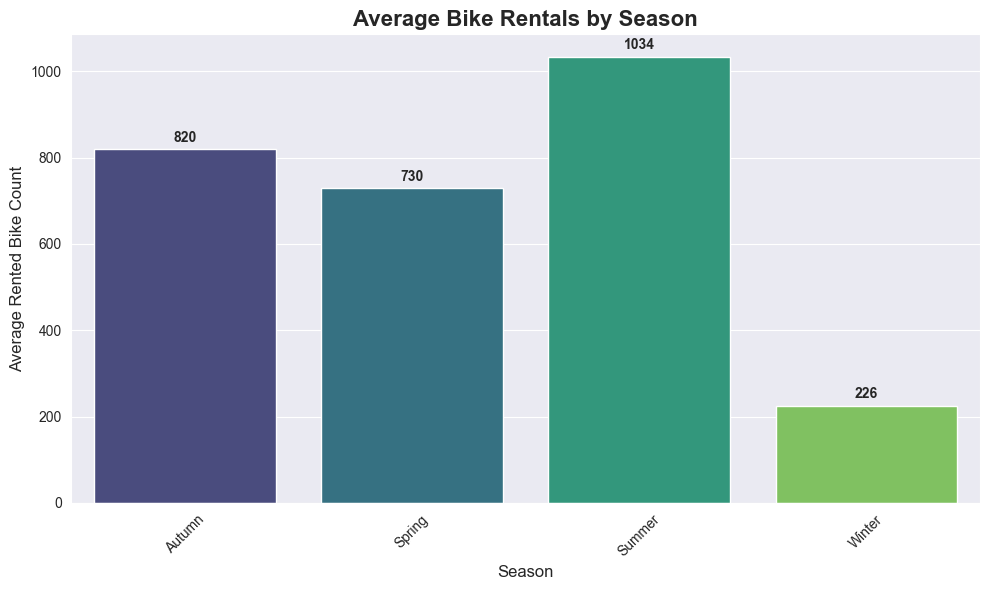

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average rentals by season
season_avg = bikes.groupby('Seasons')['Rented Bike Count'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=season_avg, x='Seasons', y='Rented Bike Count', palette='viridis')
plt.title('Average Bike Rentals by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Rented Bike Count', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for i, v in enumerate(season_avg['Rented Bike Count']):
    plt.text(i, v + 10, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## Line plot showing hourly rentals throughout the day
    - Creates a line chart that displays bike rental data over a 24-hour period
    - Shows trends and patterns in rental activity across different hours
    - Useful for identifying peak rental times and daily usage patterns


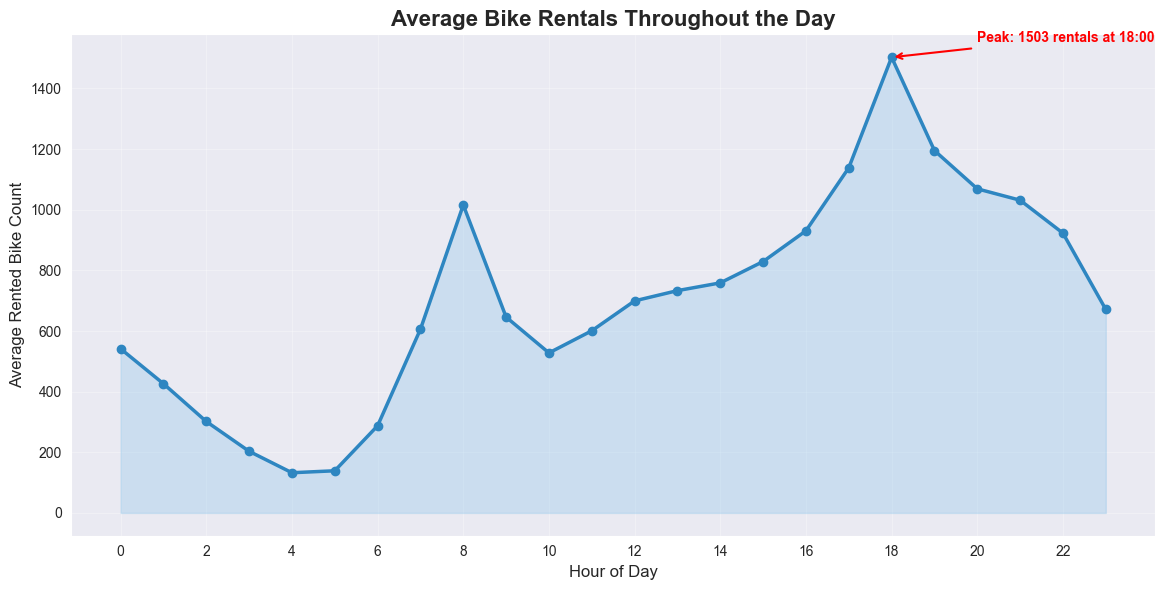

Average Bike Rentals by Hour:
 Hour  Rented Bike Count
    0         541.460274
    1         426.183562
    2         301.630137
    3         203.331507
    4         132.591781
    5         139.082192
    6         287.564384
    7         606.005479
    8        1015.701370
    9         645.983562
   10         527.821918
   11         600.852055
   12         699.441096
   13         733.246575
   14         758.824658
   15         829.186301
   16         930.621918
   17        1138.509589
   18        1502.926027
   19        1195.147945
   20        1068.964384
   21        1031.449315
   22         922.797260
   23         671.126027


In [40]:
# Line plot showing hourly rentals throughout the day
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average rentals by hour
hourly_avg = bikes.groupby('Hour')['Rented Bike Count'].mean().reset_index()

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(hourly_avg['Hour'], hourly_avg['Rented Bike Count'],
         marker='o', linewidth=2.5, markersize=6, color='#2E86C1')
plt.fill_between(hourly_avg['Hour'], hourly_avg['Rented Bike Count'], alpha=0.3, color='#85C1E9')

plt.title('Average Bike Rentals Throughout the Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Rented Bike Count', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 2))  # Show every 2 hours for better readability

# Add annotations for peak hours
max_hour = hourly_avg.loc[hourly_avg['Rented Bike Count'].idxmax(), 'Hour']
max_rentals = hourly_avg['Rented Bike Count'].max()
plt.annotate(f'Peak: {max_rentals:.0f} rentals at {max_hour}:00',
            xy=(max_hour, max_rentals), xytext=(max_hour+2, max_rentals+50),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Display the hourly data
print("Average Bike Rentals by Hour:")
print(hourly_avg.to_string(index=False))


# Heatmap showing correlation among numerical variables
- Creates a correlation matrix visualization using a heatmap
- Displays the strength and direction of relationships between numeric variables
- Color intensity typically represents correlation strength (e.g., darker colors for stronger correlations)

Numerical columns: ['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']


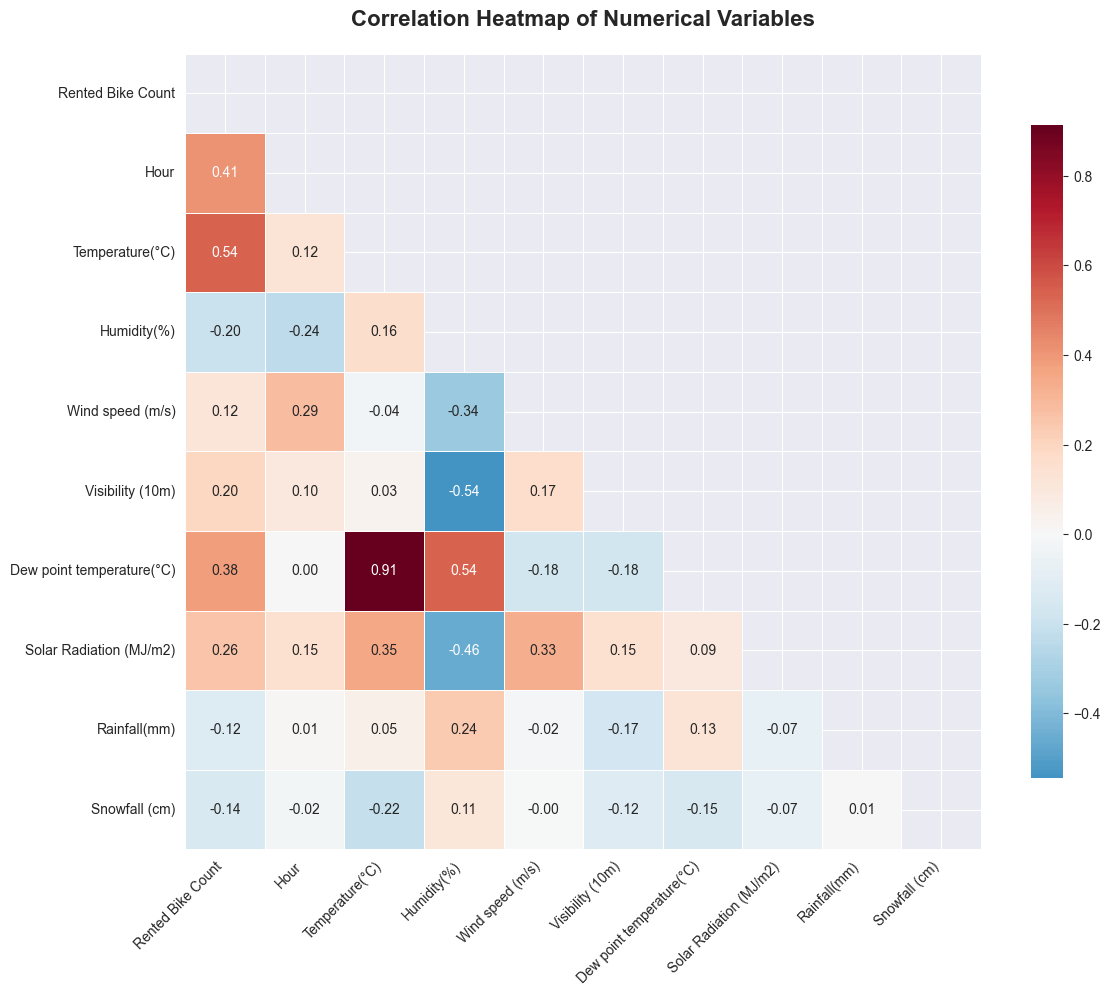


Correlation Matrix:
                           Rented Bike Count   Hour  Temperature(°C)  \
Rented Bike Count                      1.000  0.410            0.539   
Hour                                   0.410  1.000            0.124   
Temperature(°C)                        0.539  0.124            1.000   
Humidity(%)                           -0.200 -0.242            0.159   
Wind speed (m/s)                       0.121  0.285           -0.036   
Visibility (10m)                       0.199  0.099            0.035   
Dew point temperature(°C)              0.380  0.003            0.913   
Solar Radiation (MJ/m2)                0.262  0.145            0.354   
Rainfall(mm)                          -0.123  0.009            0.050   
Snowfall (cm)                         -0.142 -0.022           -0.218   

                           Humidity(%)  Wind speed (m/s)  Visibility (10m)  \
Rented Bike Count               -0.200             0.121             0.199   
Hour                          

In [41]:
# Heatmap showing correlation among numerical variables
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation analysis
numerical_cols = bikes.select_dtypes(include=[np.number]).columns
print(f"Numerical columns: {list(numerical_cols)}")

# Calculate correlation matrix
correlation_matrix = bikes[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,                    # Show correlation values
            cmap='RdBu_r',                 # Red-Blue colormap (red=positive, blue=negative)
            center=0,                      # Center colormap at 0
            square=True,                   # Make cells square-shaped
            fmt='.2f',                     # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8},      # Adjust colorbar size
            linewidths=0.5,                # Add gridlines between cells
            mask=np.triu(np.ones_like(correlation_matrix, dtype=bool))) # Show only lower triangle

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display correlation matrix as a table for detailed analysis
print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Find strongest correlations (excluding self-correlation)
correlations_flat = correlation_matrix.unstack()
correlations_flat = correlations_flat[correlations_flat != 1.0].dropna()
strongest_correlations = correlations_flat.abs().nlargest(10)

print("\nTop 10 Strongest Correlations:")
for (var1, var2), corr in strongest_correlations.items():
    original_corr = correlation_matrix.loc[var1, var2]
    direction = "positive" if original_corr > 0 else "negative"
    print(f"{var1} ↔ {var2}: {original_corr:.3f} ({direction})")

# Box plot to identify outliers in Temperature and Rented Bike Count
- Creates box-and-whisker plots for two specific variables: Temperature and Rented Bike Count
- Helps visualize data distribution and identify outliers (data points that fall outside the normal range)
- Shows quartiles, median, and potential anomalies in the data

/var/folders/dx/86cvpn0169sd3sqctx9wcxgr0000gn/T/ipykernel_73252/1193646585.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bikes, y='Temperature(°C)', ax=axes[0], palette='coolwarm')
/var/folders/dx/86cvpn0169sd3sqctx9wcxgr0000gn/T/ipykernel_73252/1193646585.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bikes, y='Rented Bike Count', ax=axes[1], palette='viridis')


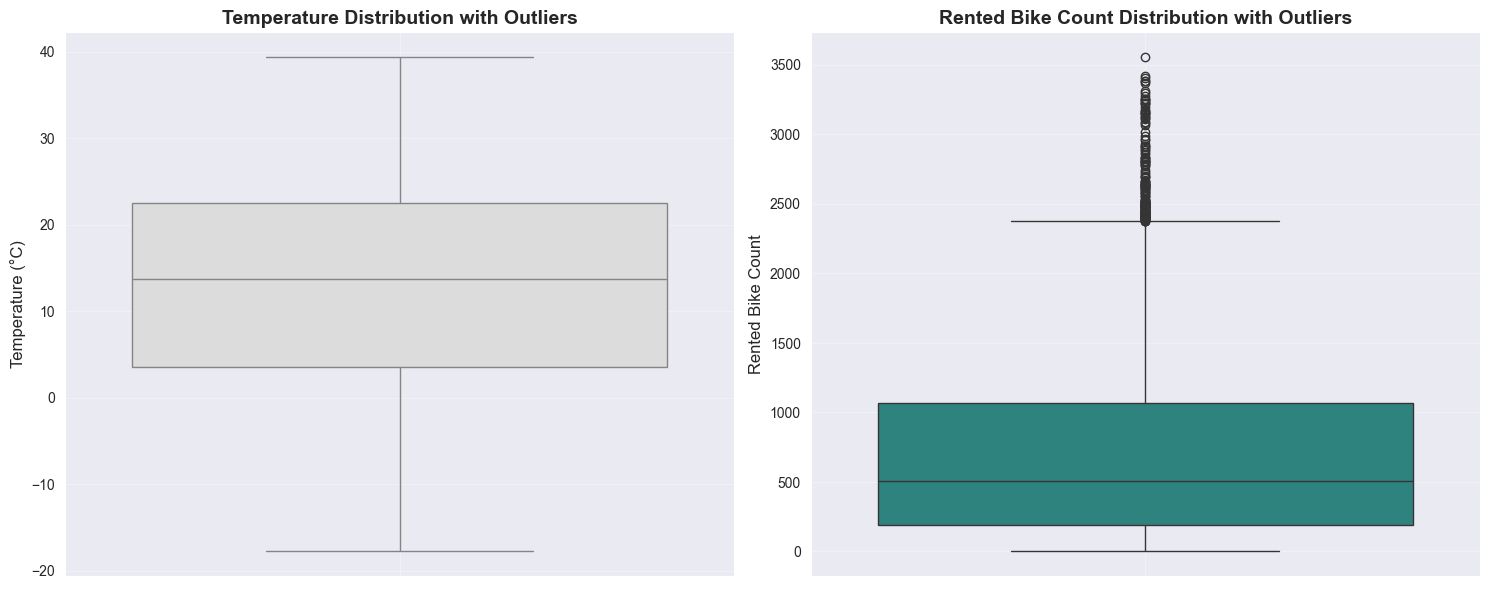

/var/folders/dx/86cvpn0169sd3sqctx9wcxgr0000gn/T/ipykernel_73252/1193646585.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_data, x='Variable', y='Values', palette='Set2')


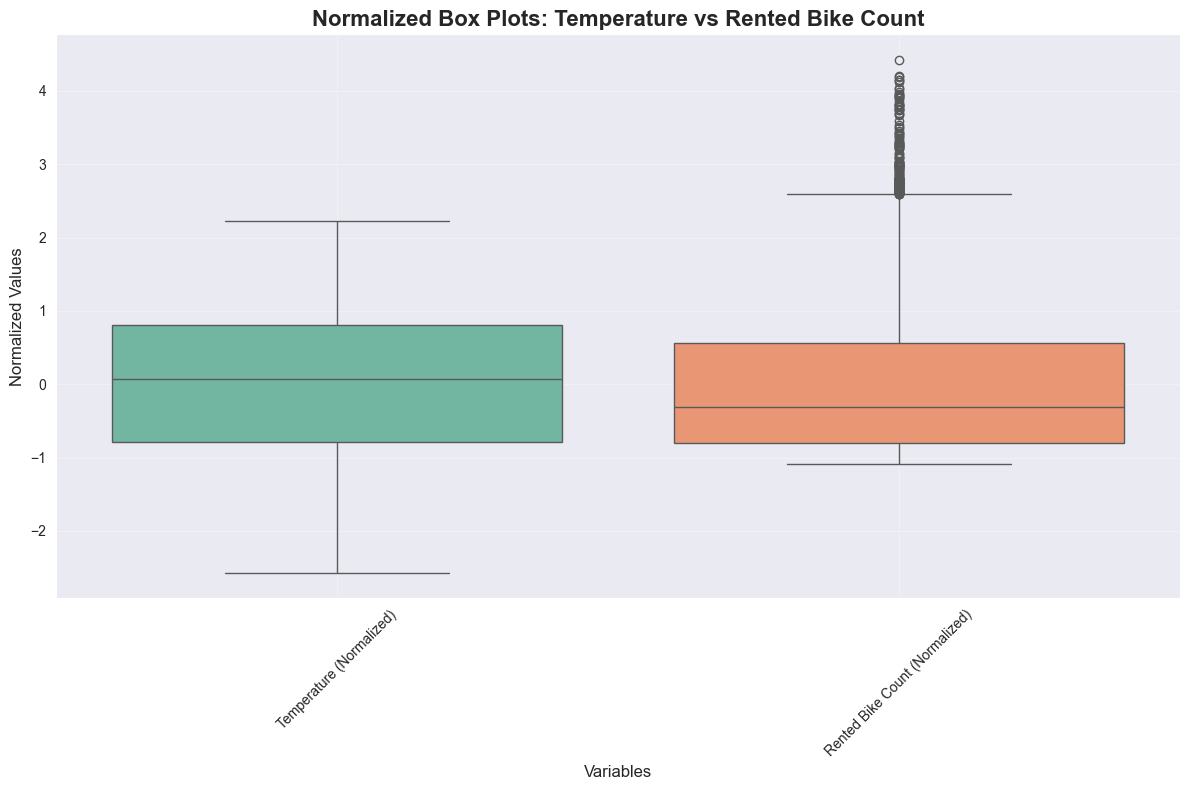

In [42]:
# Box plot to identify outliers in Temperature and Rented Bike Count
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot for Temperature
sns.boxplot(data=bikes, y='Temperature(°C)', ax=axes[0], palette='coolwarm')
axes[0].set_title('Temperature Distribution with Outliers', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Box plot for Rented Bike Count
sns.boxplot(data=bikes, y='Rented Bike Count', ax=axes[1], palette='viridis')
axes[1].set_title('Rented Bike Count Distribution with Outliers', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rented Bike Count', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Alternative: Single plot with both variables (normalized for comparison)
plt.figure(figsize=(12, 8))

# Prepare data for combined box plot
from sklearn.preprocessing import StandardScaler

# Normalize both variables for comparison
scaler = StandardScaler()
temp_normalized = scaler.fit_transform(bikes[['Temperature(°C)']])
rentals_normalized = scaler.fit_transform(bikes[['Rented Bike Count']])

# Create combined DataFrame for plotting
combined_data = pd.DataFrame({
    'Values': np.concatenate([temp_normalized.flatten(), rentals_normalized.flatten()]),
    'Variable': ['Temperature (Normalized)'] * len(temp_normalized) + ['Rented Bike Count (Normalized)'] * len(rentals_normalized)
})

sns.boxplot(data=combined_data, x='Variable', y='Values', palette='Set2')
plt.title('Normalized Box Plots: Temperature vs Rented Bike Count', fontsize=16, fontweight='bold')
plt.ylabel('Normalized Values', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical analysis of outliers
def identify_outliers(data, column):
    """Identify outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR